Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBRegressor
from xgboost import plot_importance
import pickle

import yfinance as yf
from datetime import datetime
import time

In [2]:
df = pd.read_csv('Data/trendy_threads_historical_sales.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Year    161 non-null    int64 
 1   Month   161 non-null    object
 2   Sales   161 non-null    object
dtypes: int64(1), object(2)
memory usage: 3.9+ KB


Add date column

In [3]:
df['date'] = pd.to_datetime(
    df['Month'] + ' ' + df['Year'].astype(str), 
    format='%B %Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Year    161 non-null    int64         
 1   Month   161 non-null    object        
 2   Sales   161 non-null    object        
 3   date    161 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 5.2+ KB


Add WINA (franchiser) stock value

In [4]:
wina = yf.download('WINA', start='2012-05-01')
wina.columns = wina.columns.get_level_values(0)
wina_monthly = wina['Close'].resample('MS').first().reset_index()
wina_monthly.head(5)
wina_monthly = wina_monthly.rename(columns={'Close': 'wina_price', 'Date': 'date'})
df = df.merge(wina_monthly[['date', 'wina_price']], on='date', how='left')
df.info()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Year        161 non-null    int64         
 1   Month       161 non-null    object        
 2   Sales       161 non-null    object        
 3   date        161 non-null    datetime64[ns]
 4   wina_price  161 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 6.4+ KB


Add unemployment data for years of operation

In [5]:
unemployment = pd.read_csv("Data/maricopa_county_unemployment.csv", parse_dates=["observation_date"])
unemployment = unemployment.rename(columns={"observation_date":"date","AZMARI3URN":"unemployment"})
df = df.merge(unemployment[['date', 'unemployment']])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Year          160 non-null    int64         
 1   Month         160 non-null    object        
 2   Sales         160 non-null    object        
 3   date          160 non-null    datetime64[ns]
 4   wina_price    160 non-null    float64       
 5   unemployment  160 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 7.6+ KB


Add consumer price index (CPI)

In [6]:
cpi = pd.read_csv('Data/CPI_national.csv')
cpi['observation_date'] = pd.to_datetime(cpi['observation_date'])
cpi = cpi.rename(columns={'observation_date': 'date', 'CPIAUCSL': 'cpi_usa'})
df = df.merge(cpi[['date', 'cpi_usa']])

Add inflation-adjusted WINA stock price

In [7]:
df['real_wina'] = df['wina_price'] / df['cpi_usa']

Remove '$' and ',' from 'Sales'.

In [8]:
df['Sales'] = df['Sales'].str.replace(r'[$,]', '', regex=True)
df.head()

,Year,Month,Sales,date,wina_price,unemployment,cpi_usa,real_wina
0,2012,May,128334.00,2012-05-01,42.865543,7.2,228.713,0.187421
1,2012,June,84548.58,2012-06-01,36.879566,7.8,228.524,0.161382
2,2012,July,96069.11,2012-07-01,44.989830,8.0,228.590,0.196815
3,2012,August,94120.59,2012-08-01,39.616203,7.6,229.918,0.172306
4,2012,September,73725.42,2012-09-01,38.331928,7.1,231.015,0.165928


Change 'Sales' data type to float.

In [9]:
df['Sales'] = df['Sales'].astype(float)
df.dtypes

Year                     int64
Month                   object
Sales                  float64
date            datetime64[ns]
wina_price             float64
unemployment           float64
cpi_usa                float64
real_wina              float64
dtype: object

Standardize column names

In [10]:
df = df.rename(columns={
    'Year': 'year',
    'Month': 'month',
    'Sales': 'sales'
})
df.columns

Index(['year', 'month', 'sales', 'date', 'wina_price', 'unemployment',
       'cpi_usa', 'real_wina'],
      dtype='object')

Add rolling average sales columns

In [13]:
df['last_month'] = df['sales'].shift(1)
df['2mo_rolling'] = df['sales'].shift(1).rolling(window=2).mean()
df['3mo_rolling'] = df['sales'].shift(1).rolling(window=3).mean()
df['4mo_rolling'] = df['sales'].shift(1).rolling(window=4).mean()
df['5mo_rolling'] = df['sales'].shift(1).rolling(window=5).mean()

Check best rolling average correlation to sales

In [14]:
df[['sales', 'last_month', '2mo_rolling', '3mo_rolling', '4mo_rolling', '5mo_rolling']].corr()

,sales,last_month,2mo_rolling,3mo_rolling,4mo_rolling,5mo_rolling
sales,1.000000,0.865251,0.874611,0.872230,0.877619,0.867932
last_month,0.865251,1.000000,0.966643,0.944834,0.928823,0.922596
2mo_rolling,0.874611,0.966643,1.000000,0.985407,0.970948,0.960818
3mo_rolling,0.872230,0.944834,0.985407,1.000000,0.991381,0.982065
4mo_rolling,0.877619,0.928823,0.970948,0.991381,1.000000,0.994575
5mo_rolling,0.867932,0.922596,0.960818,0.982065,0.994575,1.000000


Add column with months as integers

In [15]:
df['month_int'] = df['month'].map({'January': 1, 'February': 2, 'March': 3, 'April': 4, 
                                   'May': 5, 'June': 6, 'July': 7, 'August': 8, 'September': 9, 
                                   'October':10, 'November': 11, 'December': 12})

sns.pairplot(df)
plt.show()
correlations = df.corr(numeric_only=True)
correlations

In [16]:
mask = df['year'] == 2019
max = df.loc[mask, 'sales'].idxmax()
df.loc[max]

year                           2019
month                          July
sales                     155306.69
date            2019-07-01 00:00:00
wina_price                 144.1483
unemployment                    4.6
cpi_usa                     255.802
real_wina                  0.563515
last_month                 120937.7
2mo_rolling              120800.265
3mo_rolling           116382.303333
4mo_rolling              117572.025
5mo_rolling              113454.656
month_int                         7
Name: 86, dtype: object

### Create a model using only month and year to predict sales ###

In [17]:
df.columns

Index(['year', 'month', 'sales', 'date', 'wina_price', 'unemployment',
       'cpi_usa', 'real_wina', 'last_month', '2mo_rolling', '3mo_rolling',
       '4mo_rolling', '5mo_rolling', 'month_int'],
      dtype='object')

Split train and test data

In [18]:
y = df['sales']
X = df[['month_int', 'year']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)

Create and fit the model

In [19]:
rf = RandomForestRegressor(n_estimators=50, random_state=42, max_depth=3,
                           min_samples_leaf=3, min_samples_split=4)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of th

Test the model

In [20]:
rf_y_pred = rf.predict(X_test)
rf_r2 = r2_score(y_test, rf_y_pred)
rf_error = mean_absolute_error(y_test, rf_y_pred)
rf_percent_error = mean_absolute_percentage_error(y_test, rf_y_pred)
rf_norm_error = rf_error / np.std(df['sales'])

View model utility

In [21]:
print(f'\nR2: {rf_r2:.3f}\n'
      f'Error in dollars: ${rf_error:,.3f}\n'
      f'Error in percent: {rf_percent_error*100:.3f}%\n'
      f'Normalized Error: {rf_norm_error:.3}')


R2: 0.744
Error in dollars: $16,456.518
Error in percent: 13.897%
Normalized Error: 0.322


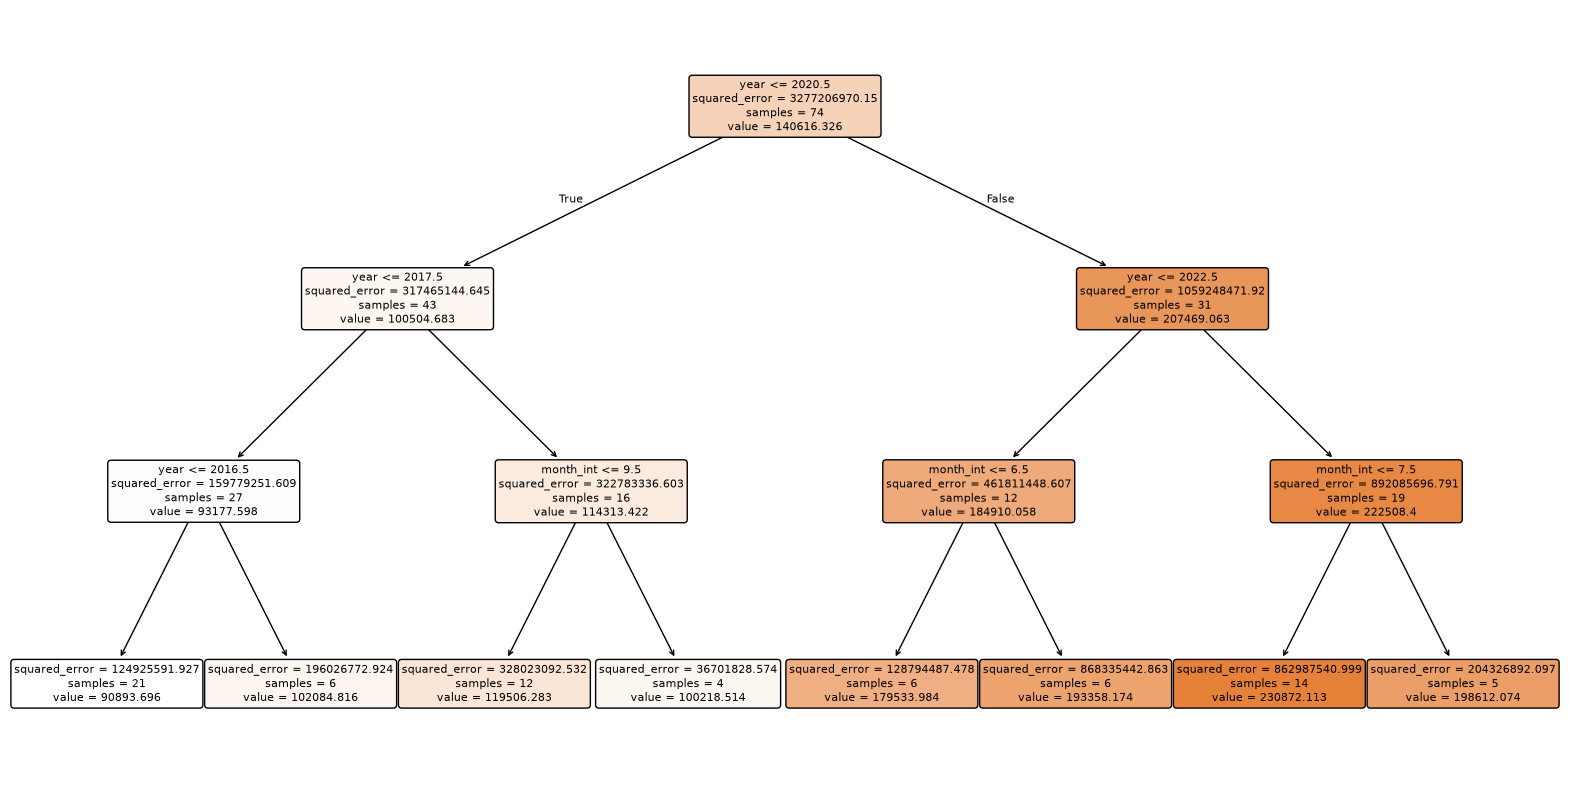

In [22]:
plt.figure(figsize=(20, 10))
plot_tree(
    rf.estimators_[0], 
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=8
    )
plt.show()

### Test Parameters and features for an XGBoost model ###

Test parameters

In [23]:
param_dist = {
    'max_depth': randint(3, 8),
    'min_child_weight': randint(1, 6),
    'learning_rate': uniform(0.01, 0.2),
    'n_estimators': randint(20, 200),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

In [24]:
xgb_rand = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42),
    param_distributions=param_dist,
    n_iter=25,
    scoring='r2',
    cv=5,
    random_state=42)

In [25]:
xgb_rand.fit(X_train, y_train)
print("Best parameters found:", xgb_rand.best_params_)
print("Best R² (CV):", xgb_rand.best_score_)

Best parameters found: {'colsample_bytree': np.float64(0.6557325817623503), 'learning_rate': np.float64(0.13088347585556345), 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 55, 'subsample': np.float64(0.9771414282231924)}
Best R² (CV): 0.9105231016560473


In [26]:
xgb_best = xgb_rand.best_estimator_

y_pred = xgb_best.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
norm_error = mae / np.std(df['sales'])

print(f"Test R²: {r2:.3f}")
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"MAPE: {mape*100:.2f}%")
print(f"Normalized Error: {norm_error:.3f}")

Test R²: 0.768
Mean Absolute Error: $15,754.03
MAPE: 13.89%
Normalized Error: 0.308


Test X values

In [28]:
feature_sets = [
    ['year', 'month_int', 'real_wina'],
    ['year', 'month_int', 'real_wina', 'last_month'],
    ['year', 'month_int', 'real_wina', '2mo_rolling'],
    ['year', 'month_int', 'real_wina', 'last_month', '2mo_rolling'],
    ['year', 'month_int', 'real_wina', 'last_month', '2mo_rolling', '4mo_rolling', '5mo_rolling']
]

param_dist = {
    'max_depth': randint(3, 8),
    'min_child_weight': randint(1, 6),
    'learning_rate': uniform(0.01, 0.2),
    'n_estimators': randint(20, 200),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

Loop through each feature set

In [29]:
results = []
for features in feature_sets:
    print(f"\nTesting feature set: {features}")
    X = df[features]
    y = df['sales']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    xgb_rand = RandomizedSearchCV(
        XGBRegressor(objective='reg:squarederror', random_state=42),
        param_distributions=param_dist,
        n_iter=25,
        scoring='r2',
        cv=5,
        random_state=42
    )

    xgb_rand.fit(X_train, y_train)

    y_pred = xgb_rand.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    results.append({
        'features': features,
        'cv_r2': xgb_rand.best_score_,
        'test_r2': r2,
        'mae': mae,
        'mape': mape,
        'best_params': xgb_rand.best_params_
    })


Testing feature set: ['year', 'month_int', 'real_wina']

Testing feature set: ['year', 'month_int', 'real_wina', 'last_month']

Testing feature set: ['year', 'month_int', 'real_wina', '2mo_rolling']

Testing feature set: ['year', 'month_int', 'real_wina', 'last_month', '2mo_rolling']

Testing feature set: ['year', 'month_int', 'real_wina', 'last_month', '2mo_rolling', '4mo_rolling', '5mo_rolling']


Show best feature set

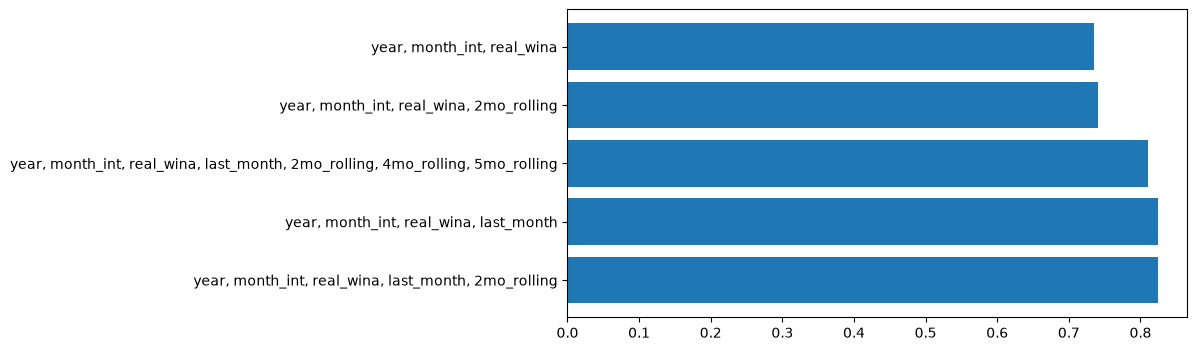

In [ ]:
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by='test_r2', ascending=False)
plt.figure(figsize=(8,4))
plt.barh(range(len(results_df_sorted)), results_df_sorted['test_r2'], align='center'd)
plt.yticks(range(len(results_df_sorted)), [', '.join(fs) for fs in results_df_sorted['features']])
plt.show()

Create an XGBoost model using best perameters and features

In [31]:
df.columns
y = df['sales']
X = df[['year', 'month_int', 'real_wina', 'last_month', '2mo_rolling']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

cv_params = {'max_depth': [4,5],
             'min_child_weight': [3,5],
             'learning_rate': [.1],
             'n_estimators': [5,10,15],
             'subsample': [.7],
             'colsample_bytree': [.7]}

scoring =   {'r2': 'r2',
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error'}

xgb_cv = GridSearchCV(xgb, 
                      cv_params,
                      scoring=scoring,
                      cv=5,
                      refit='r2')


xgb_cv = xgb_cv.fit(X_train, y_train)

print("Best parameters:", xgb_cv.best_params_)
print("Best R² (CV):", xgb_cv.best_score_)

xgb_y_pred = xgb_cv.predict(X_test)
xgb_r2 = r2_score(y_test, xgb_y_pred)
xgb_error = mean_absolute_error(y_test, xgb_y_pred)
xgb_percent_error = mean_absolute_percentage_error(y_test, xgb_y_pred)
xgb_norm_error = xgb_error / np.std(df['sales'])

print(f'\nR2: {xgb_r2:.3f}\n'
      f'Error in dollars: ${xgb_error:,.3f}\n'
      f'Error in percent: {xgb_percent_error*100:.3f}%\n'
      f'Normalized Error: {xgb_norm_error:.3}')

best_r2_dif = xgb_cv.best_score_ - xgb_r2
if  best_r2_dif > -0.05 and best_r2_dif < 0.05:
    print('The model does not over fit the data.')
else:
    print('The model may overfit the data.')
best_r2_dif

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 15, 'subsample': 0.7}
Best R² (CV): 0.809843323032401

R2: 0.788
Error in dollars: $15,489.330
Error in percent: 14.707%
Normalized Error: 0.303
The model does not over fit the data.


np.float64(0.021831127609341028)